## Importy

In [2]:
import os
import re
from scripts.cvrp_ilp import solve_cvrp_ilp as solve_cvrp_ilp_basic
from scripts.cvrp_ilp_opt import solve_cvrp_ilp as solve_cvrp_ilp_opt
from scripts.cvrp_ilp_warm import solve_cvrp_ilp as solve_cvrp_ilp_warm
from scripts.cvrp_genetic import solve_cvrp_ga
from scripts.cvrp_hybrid import solve_cvrp_hybrid
from scripts.cvrp_hybrid_candidate import solve_cvrp_hybrid_candidate as solve_cvrp_hybrid_candidate

from scripts.plot_utils import plot_cbc_log, plot_ga_log, plot_hybrid_log

## Funkcje Pomocnicze

In [3]:
def get_optimal_cost(vrp_filepath):
    sol_filepath = vrp_filepath.replace('.vrp', '.sol')
    if os.path.exists(sol_filepath):
        with open(sol_filepath, 'r') as f:
            for line in f:
                if line.startswith('Cost'):
                    match = re.search(r'Cost\s+(\d+)', line)
                    if match:
                        return float(match.group(1))
    return None


def run_experiments(instances, solver_function, **kwargs):
    for inst in instances:
        if os.path.exists(inst):
            try:
                opt_cost = get_optimal_cost(inst)
                solver_function(inst, **kwargs)

                if solver_function.__name__ == 'solve_cvrp_ga':
                    plot_ga_log(optimum_cost=opt_cost)
                    
                elif solver_function.__name__ in ['solve_cvrp_hybrid', 'solve_cvrp_hybrid_candidate']:
                    plot_hybrid_log(optimum_cost=opt_cost)

                else:
                    plot_cbc_log(optimum_cost=opt_cost)

            except Exception as e:
                print(f"Błąd podczas analizy {inst}: {e}")
        else:
            print(f"Plik {inst} nie istnieje!")

## Instancje

In [4]:
instances = [
    os.path.join('data', 'E', 'E-n101-k8.vrp')
]

## Algorytm ILP Klasyczny

Wczytano 100 klientów, depot: 1, pojemność: 200, maks. ciężarówek: 8
Uruchamianie solvera
Czas wykonania: 60.23 s
Status: Optimal
Minimal tour: 1543.0
Routes: [[1, 17, 46, 18, 85, 50, 48, 47, 9, 83, 19, 90, 7, 28, 1], [1, 23, 24, 68, 26, 40, 58, 43, 38, 98, 100, 16, 42, 1], [1, 53, 8, 63, 37, 49, 20, 12, 64, 65, 33, 89, 32, 70, 1], [1, 60, 99, 88, 56, 81, 78, 51, 77, 13, 27, 30, 4, 25, 79, 35, 36, 1], [1, 67, 31, 21, 72, 71, 11, 91, 66, 2, 29, 95, 94, 1], [1, 87, 6, 84, 61, 62, 92, 101, 86, 44, 1], [1, 93, 76, 75, 74, 22, 69, 55, 34, 52, 82, 10, 80, 97, 1], [1, 96, 59, 54, 41, 3, 14, 73, 5, 57, 15, 45, 39, 1]]
Zapisano statystyki eksperymentu do results\experiments.csv


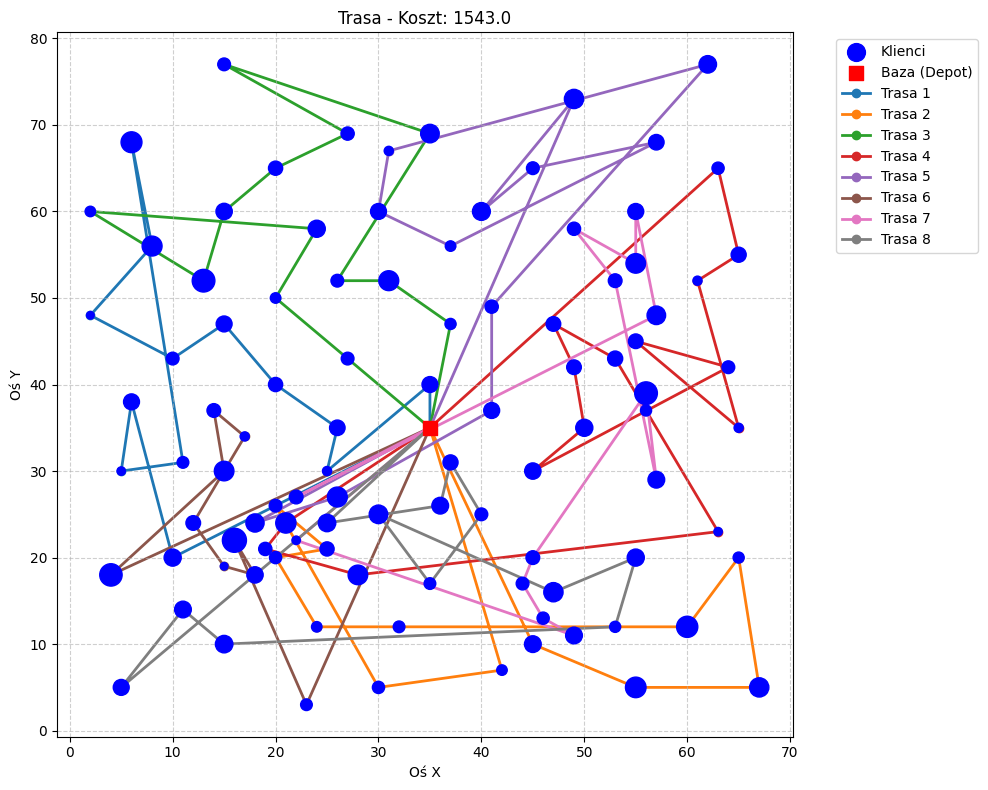

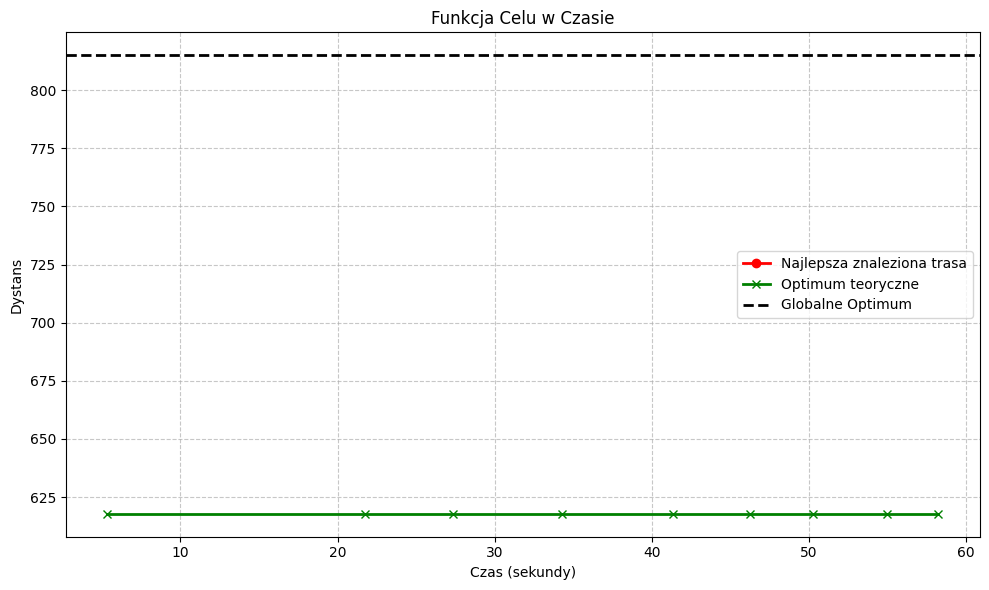

In [5]:
run_experiments(instances, solve_cvrp_ilp_basic, time_limit=60)

## Algorytm ILP z Optymalizacjami

Wczytano 100 klientów, depot: 1, pojemność: 200, maks. ciężarówek: 8
Uruchamianie solvera
Czas wykonania: 60.35 s
Status: Not Solved
Zapisano statystyki eksperymentu do results\experiments.csv


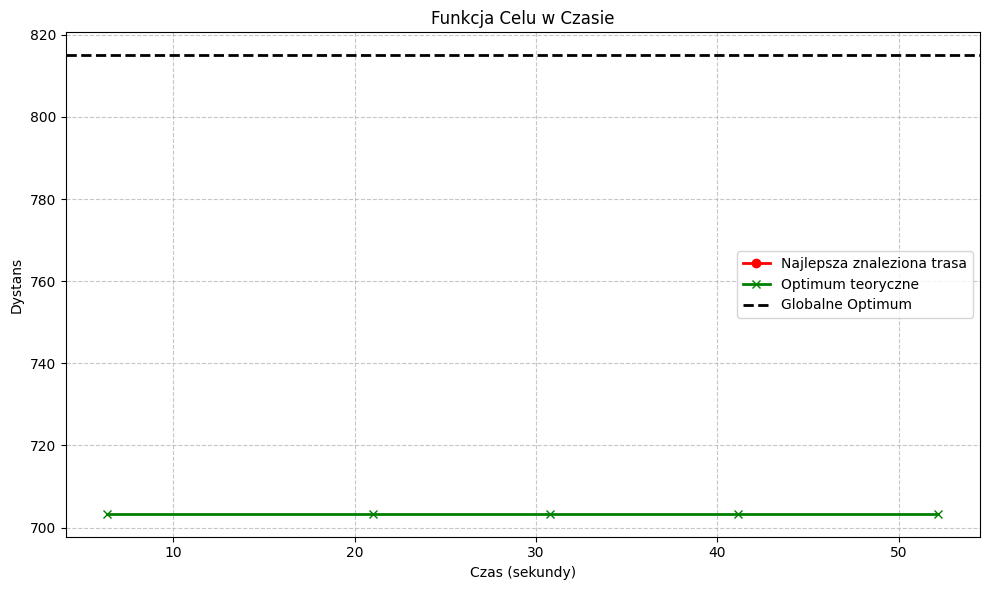

In [6]:
run_experiments(instances, solve_cvrp_ilp_opt, time_limit=60)

## Algorytm ILP z Optymalizacjami i 'Warm Start NN'

Wczytano 100 klientów, depot: 1, pojemność: 200, maks. ciężarówek: 8
Uruchamianie solvera
Czas wykonania: 3600.84 s
Status: Optimal
Minimal tour: 1176.0
Routes: [[1, 14, 88, 3, 58, 16, 44, 43, 101, 99, 62, 17, 45, 15, 39, 18, 1], [1, 28, 29, 27, 13, 81, 69, 78, 4, 80, 34, 82, 79, 1], [1, 53, 19, 61, 6, 85, 84, 9, 46, 83, 49, 48, 37, 20, 8, 1], [1, 54, 59, 41, 22, 74, 73, 75, 23, 42, 76, 57, 24, 68, 56, 25, 1], [1, 55, 5, 40, 26, 11, 63, 64, 33, 67, 66, 65, 1], [1, 70, 2, 51, 77, 30, 35, 36, 72, 10, 52, 21, 31, 71, 32, 89, 12, 91, 1], [1, 87, 50, 1], [1, 90, 7, 95, 96, 98, 93, 60, 100, 97, 94, 86, 92, 38, 47, 1]]
Zapisano statystyki eksperymentu do results\experiments.csv


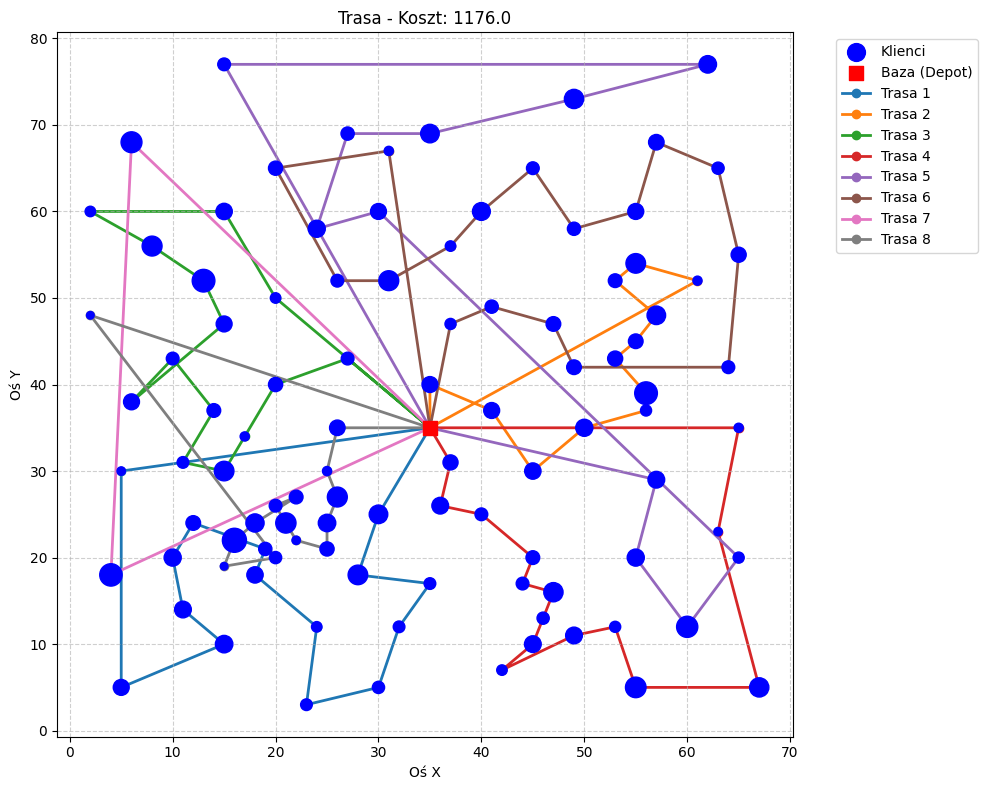

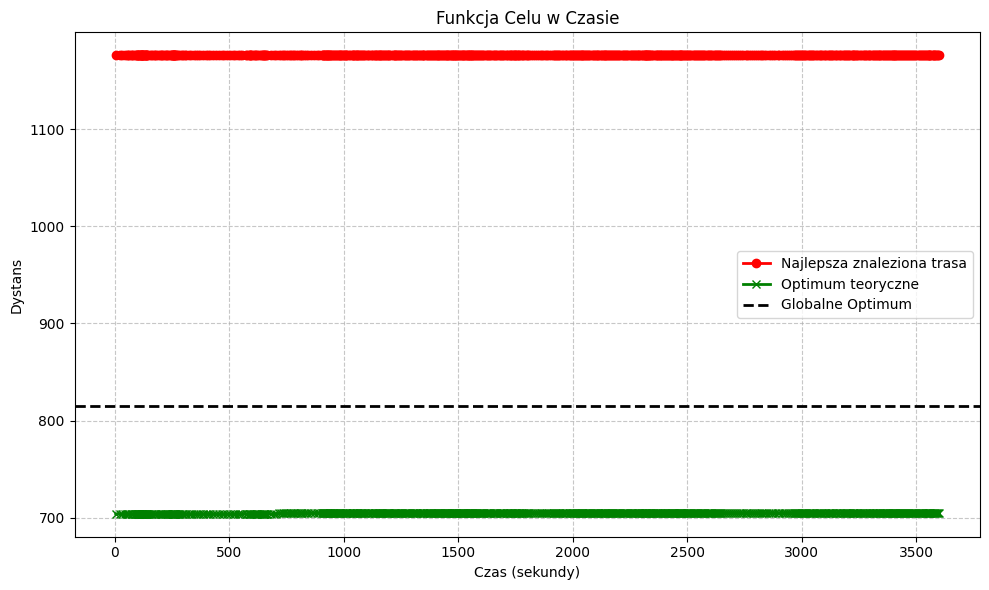

In [7]:
run_experiments(instances, solve_cvrp_ilp_warm, time_limit=3600)

## Algorytm Genetyczny

Wczytano 100 klientów, depot: 1, pojemność: 200, maks. ciężarówek: 8
Parametry GA: Populacja=1000, Pokolenia=10000, Limit czasu=3600s
Uruchamianie algorytmu genetycznego
Czas wykonania: 855.29 s
Minimal tour (Feasible): 1597
Routes: [[1, 88, 38, 43, 15, 17, 45, 39, 16, 58, 5, 55, 69, 1], [1, 53, 8, 2, 31, 82, 36, 66, 72, 34, 35, 79, 25, 68, 73, 1], [1, 95, 100, 94, 60, 7, 85, 62, 61, 18, 87, 93, 90, 59, 29, 1], [1, 10, 51, 52, 11, 91, 20, 48, 50, 37, 71, 74, 23, 42, 41, 1], [1, 33, 67, 65, 47, 6, 86, 98, 96, 24, 56, 26, 81, 1], [1, 28, 64, 12, 63, 32, 92, 3, 22, 4, 30, 80, 27, 1], [1, 49, 9, 83, 89, 21, 70, 14, 97, 19, 84, 46, 101, 99, 54, 1], [1, 44, 76, 75, 57, 40, 13, 78, 77, 1]]
Zapisano statystyki eksperymentu do results\experiments.csv


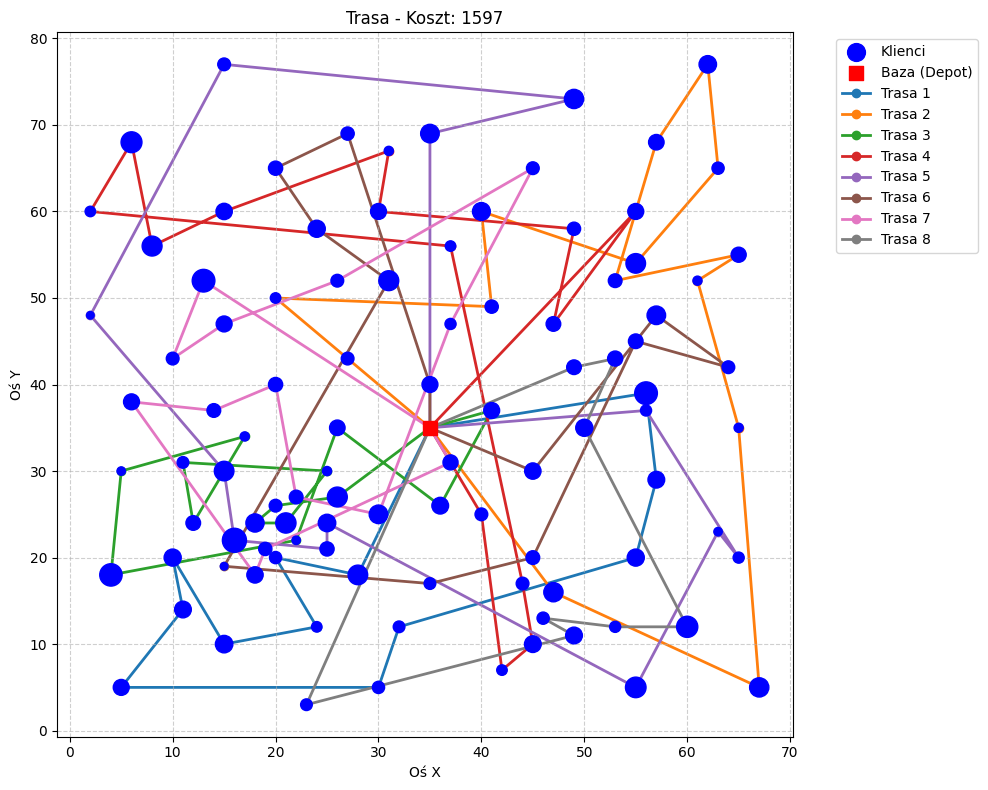

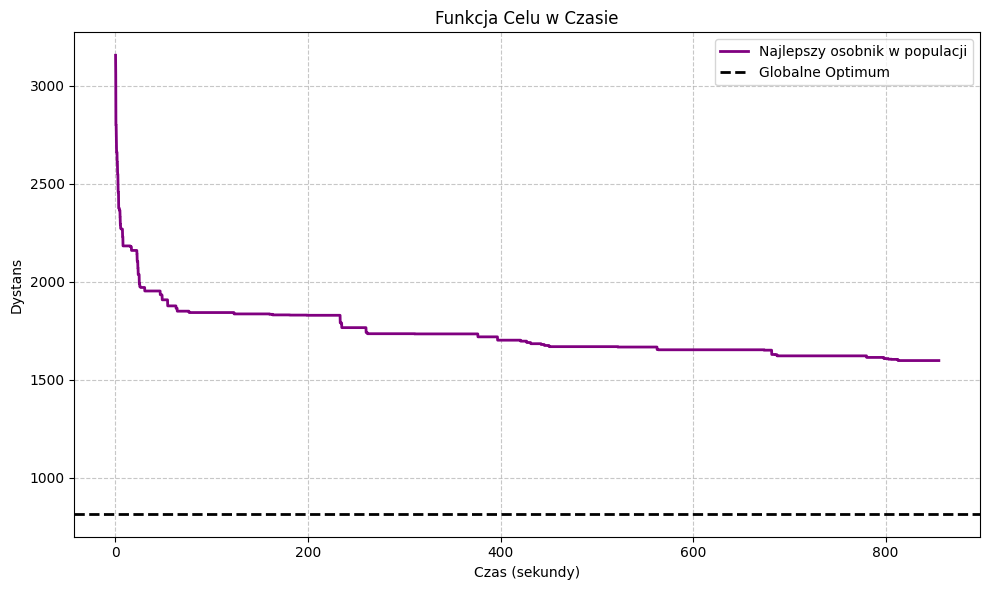

In [8]:
run_experiments(instances, solve_cvrp_ga, time_limit=3600, population_size=1000, generations=10000, seed=42)

## Algorytm Hybrydowy

Krok 1: Inicjalizacja Algorytmem Genetycznym
Wczytano 100 klientów, depot: 1, pojemność: 200, maks. ciężarówek: 8
Parametry GA: Populacja=1000, Pokolenia=5000, Limit czasu=1200s
Uruchamianie algorytmu genetycznego
Czas wykonania: 423.11 s
Minimal tour (Feasible): 1689
Routes: [[1, 43, 39, 17, 15, 45, 16, 5, 55, 69, 53, 8, 2, 1], [1, 82, 36, 66, 72, 31, 34, 35, 79, 25, 68, 73, 88, 1], [1, 95, 60, 58, 7, 94, 85, 62, 18, 87, 100, 61, 90, 93, 59, 1], [1, 29, 10, 51, 52, 11, 91, 20, 48, 50, 37, 71, 74, 23, 42, 41, 1], [1, 33, 67, 65, 47, 6, 86, 98, 96, 56, 26, 24, 81, 1], [1, 28, 27, 80, 30, 4, 64, 12, 63, 32, 92, 3, 22, 1], [1, 49, 9, 46, 84, 83, 89, 21, 70, 14, 97, 38, 101, 99, 54, 1], [1, 19, 44, 57, 40, 75, 76, 13, 77, 78, 1]]

Krok 2: Uruchamianie solvera ILP
Czas wykonania: 2400.81 s
Status: Optimal
Minimal tour: 1689.0
Routes: [[1, 19, 44, 57, 40, 75, 76, 13, 77, 78, 1], [1, 28, 27, 80, 30, 4, 64, 12, 63, 32, 92, 3, 22, 1], [1, 29, 10, 51, 52, 11, 91, 20, 48, 50, 37, 71, 74, 23, 42, 

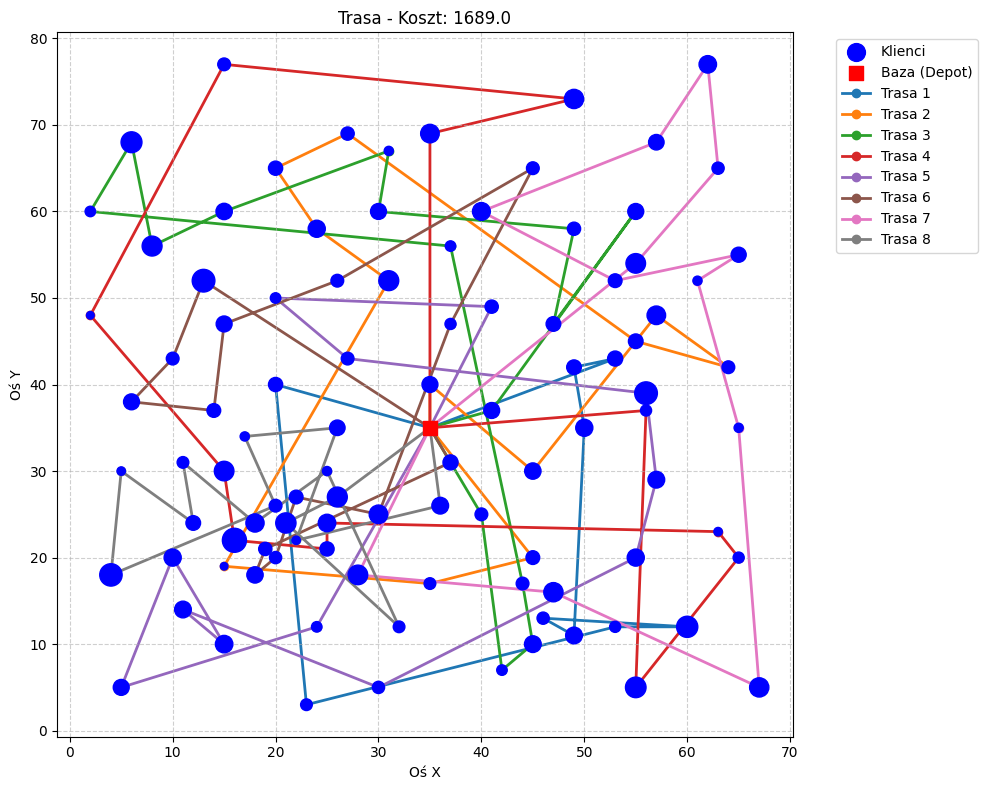

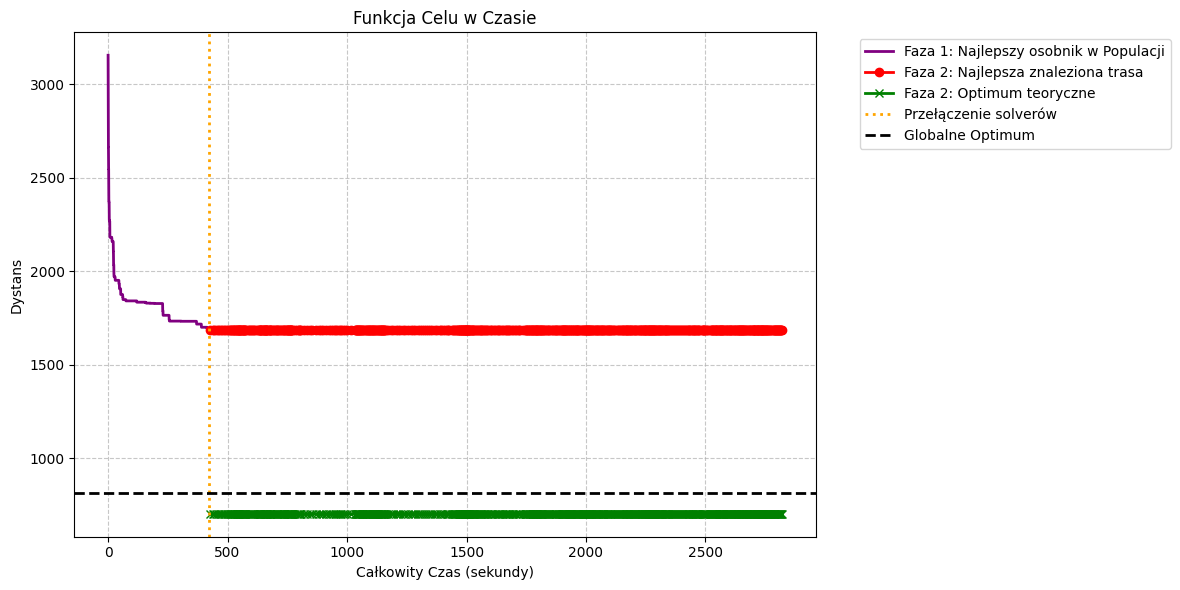

In [9]:
run_experiments(instances, solve_cvrp_hybrid, ga_time_limit=1200, ilp_time_limit=2400, population_size=1000, generations=5000, seed=42)

## Algorytm Hybrydowy z ograniczeniem krawędzi

Krok 1: Inicjalizacja Algorytmem Genetycznym
Wczytano 100 klientów, depot: 1, pojemność: 200, maks. ciężarówek: 8
Parametry GA: Populacja=1000, Pokolenia=10000, Limit czasu=1800s
Uruchamianie algorytmu genetycznego
Czas wykonania: 852.64 s
Minimal tour (Feasible): 1597
Routes: [[1, 88, 38, 43, 15, 17, 45, 39, 16, 58, 5, 55, 69, 1], [1, 53, 8, 2, 31, 82, 36, 66, 72, 34, 35, 79, 25, 68, 73, 1], [1, 95, 100, 94, 60, 7, 85, 62, 61, 18, 87, 93, 90, 59, 29, 1], [1, 10, 51, 52, 11, 91, 20, 48, 50, 37, 71, 74, 23, 42, 41, 1], [1, 33, 67, 65, 47, 6, 86, 98, 96, 24, 56, 26, 81, 1], [1, 28, 64, 12, 63, 32, 92, 3, 22, 4, 30, 80, 27, 1], [1, 49, 9, 83, 89, 21, 70, 14, 97, 19, 84, 46, 101, 99, 54, 1], [1, 44, 76, 75, 57, 40, 13, 78, 77, 1]]

Krok 2: Uruchamianie solvera ILP z filtrowaniem krawędzi
Czas wykonania: 1800.45 s
Status: Optimal
Minimal tour: 1358.0
Routes: [[1, 21, 31, 33, 64, 47, 49, 89, 70, 2, 28, 29, 1], [1, 32, 71, 11, 91, 12, 63, 48, 20, 8, 19, 53, 66, 51, 1], [1, 44, 88, 97, 95, 100

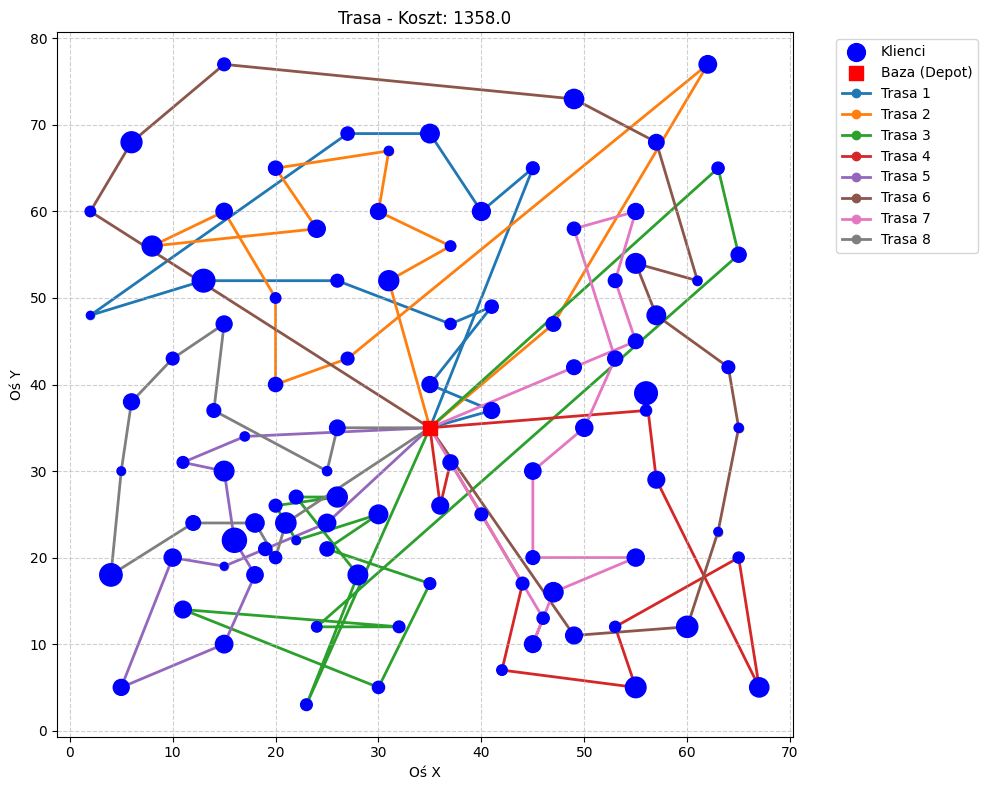

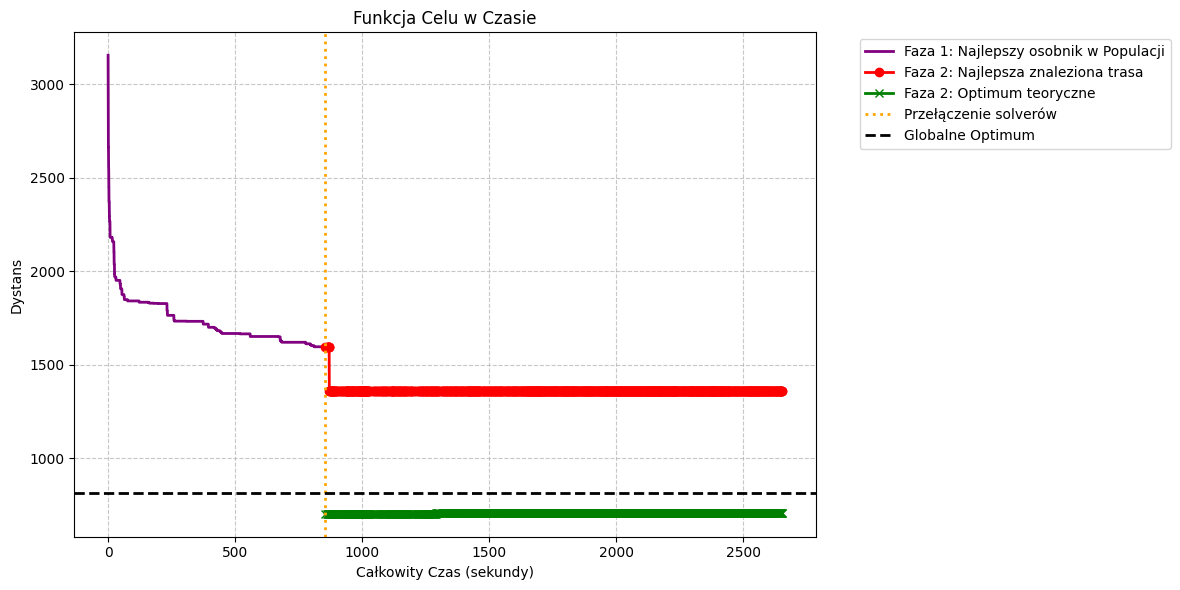

In [10]:
run_experiments(instances, solve_cvrp_hybrid_candidate, ga_time_limit=1800, ilp_time_limit=1800, population_size=1000, generations=10000, seed=42)